# Лабораторная работа № 4.1 — Задача Коши: Эйлер, Рунге–Кутта и Адамс

Вариант 6. Запускай ячейки сверху вниз. Все исходные данные заданы в ноутбуке, поэтому его можно открыть отдельно от файлов input.txt и output.txt.

Вводим z=y′, чтобы заменить уравнение второго порядка системой y′=z, z′=−4xz−(4x²+2)y. Сравниваем три метода с точным решением.

## Исходные данные

Числа ниже соответствуют файлу input.txt этой работы.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from typing import List

rows = [[1.0], [1.0], [0.0, 1.0], [0.1]]
y0, z0, interval, h = rows[0][0], rows[1][0], rows[2], rows[3][0]
print('Начальные условия:', y0, z0, 'отрезок:', interval, 'h =', h)

Начальные условия: 1.0 1.0 отрезок: [0.0, 1.0] h = 0.1


## Правая часть и метод Эйлера

Эйлер использует наклон в начале каждого шага. Новые y и z вычисляются из одного и того же старого состояния.

In [2]:
def exact_solution(x):
    return (1 + x) * math.exp(-x * x)


def f(x, y, z):
    return -4 * x * z - (4 * x * x + 2) * y


def make_grid(interval, h):
    l, r = interval
    if not all(math.isfinite(v) for v in (l, r, h)) or h <= 0 or r <= l:
        raise ValueError("Expected a finite interval l < r and h > 0")
    n = round((r - l) / h)
    if n < 1 or not math.isclose(n * h, r - l, rel_tol=1e-12, abs_tol=1e-14):
        raise ValueError("The step must divide the interval into an integer number of parts")
    return [l + i * h for i in range(n)] + [r]


def euler_method(y0, z0, interval, h):
    x = make_grid(interval, h)
    y = [y0]
    z = z0
    for i in range(len(x) - 1):
        y.append(y[i] + h * z)
        z += h * f(x[i], y[i], z)
    return x, y


def runge_romberg(coarse, fine, order):
    """Оценка погрешности на мелкой сетке в общих узлах."""
    if len(fine) != 2 * len(coarse) - 1:
        raise ValueError("Expected nested grids with step ratio 2")
    return max(abs(a - fine[2*i]) for i, a in enumerate(coarse)) / (2**order - 1)

In [3]:
x, y_euler = euler_method(y0, z0, interval, h)
print('Первый шаг Эйлера:', y_euler[1], 'точно:', exact_solution(x[1]))

Первый шаг Эйлера: 1.1 точно: 1.089054817124085


## Методы четвёртого порядка

Рунге–Кутта использует четыре оценки наклона на шаге. Адамс использует четыре предыдущих узла; первые три получает методом Рунге–Кутты.

In [4]:
def runge_kutta_method(y0, z0, interval, h):
    x = make_grid(interval, h)
    y = [y0]
    z = [z0]
    for i in range(len(x) - 1):
        k1 = h * z[i]
        l1 = h * f(x[i], y[i], z[i])
        k2 = h * (z[i] + l1 / 2)
        l2 = h * f(x[i] + h / 2, y[i] + k1 / 2, z[i] + l1 / 2)
        k3 = h * (z[i] + l2 / 2)
        l3 = h * f(x[i] + h / 2, y[i] + k2 / 2, z[i] + l2 / 2)
        k4 = h * (z[i] + l3)
        l4 = h * f(x[i] + h, y[i] + k3, z[i] + l3)
        y.append(y[i] + (k1 + 2 * k2 + 2 * k3 + k4) / 6)
        z.append(z[i] + (l1 + 2 * l2 + 2 * l3 + l4) / 6)
    return x, y, z


def adams_method(y0, z0, interval, h):
    x, y, z = runge_kutta_method(y0, z0, interval, h)
    y, z = y[:4], z[:4]
    for i in range(3, len(x) - 1):
        z.append(z[i] + h * (55 * f(x[i], y[i], z[i]) - 59 * f(x[i - 1], y[i - 1], z[i - 1]) + 37 * f(x[i - 2], y[i - 2], z[i - 2]) - 9 * f(x[i - 3], y[i - 3], z[i - 3])) / 24)
        y.append(y[i] + h * (55 * z[i] - 59 * z[i - 1] + 37 * z[i - 2] - 9 * z[i - 3]) / 24)
    return x, y

In [5]:
_, y_rk, z_rk = runge_kutta_method(y0, z0, interval, h)
_, y_adams = adams_method(y0, z0, interval, h)
solutions = {'Эйлер': y_euler, 'Рунге–Кутта': y_rk, 'Адамс': y_adams}
for name, values in solutions.items():
    error = max(abs(value-exact_solution(t)) for t,value in zip(x, values))
    print(name, 'максимальная ошибка:', error)

Эйлер максимальная ошибка: 0.10108941286249284
Рунге–Кутта максимальная ошибка: 8.397865074116773e-06
Адамс максимальная ошибка: 0.0014158994917885526


## График

График показывает результат вычисления на тех же исходных данных.

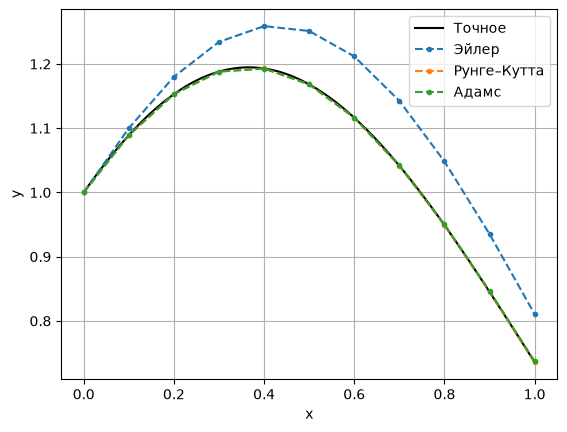

In [6]:
dense = np.linspace(*interval, 400)
plt.plot(dense, [exact_solution(t) for t in dense], color='black', label='Точное')
for name, values in solutions.items():
    plt.plot(x, values, 'o--', markersize=3, label=name)
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend()
plt.show()

## Самопроверка

Повтори расчёт с шагом h/2 и оцени ошибку методом Рунге–Ромберга в общих узлах.

In [7]:
for name, method, order in [('Эйлер',euler_method,1),('Рунге–Кутта',runge_kutta_method,4),('Адамс',adams_method,4)]:
    _, coarse, *_ = method(y0, z0, interval, h)
    _, fine, *_ = method(y0, z0, interval, h/2)
    print(name, 'Рунге–Ромберг:', runge_romberg(coarse, fine, order))
assert max(abs(v-exact_solution(t)) for t,v in zip(x,y_rk)) < 1e-4

Эйлер Рунге–Ромберг: 0.053258806459210994
Рунге–Кутта Рунге–Ромберг: 5.248911532233317e-07
Адамс Рунге–Ромберг: 8.744597892595222e-05
